In [1]:
# Cube Alchemy AdventureWorks Demo
import pandas as pd
from cube_alchemy import Hypercube
import matplotlib.pyplot as plt

from pathlib import Path

current_dir = Path.cwd()
#print(f"Current working directory: {current_dir}")

In [2]:
from tables import tables
print(tables.keys())

dict_keys(['accounts', 'actuals', 'budget', 'business_unit_dim', 'calendar_dim', 'cost_center_dim', 'location_dim', 'pnl_report_mapping', 'project_dim', 'vendor_dim'])


In [3]:
# rename amount columns in all tables to "amount (table_name)"
for table_name, df in tables.items():
    if 'amount' in df.columns:
        df.rename(columns={'amount': f'amount ({table_name})'}, inplace=True)
    # if 'account_number' convert into a int and then into a str
    if 'account_number' in df.columns:
        df['account_number'] = df['account_number'].astype(int).astype(str)


Hypercube initialization failed due to cyclic relationships or other issues.


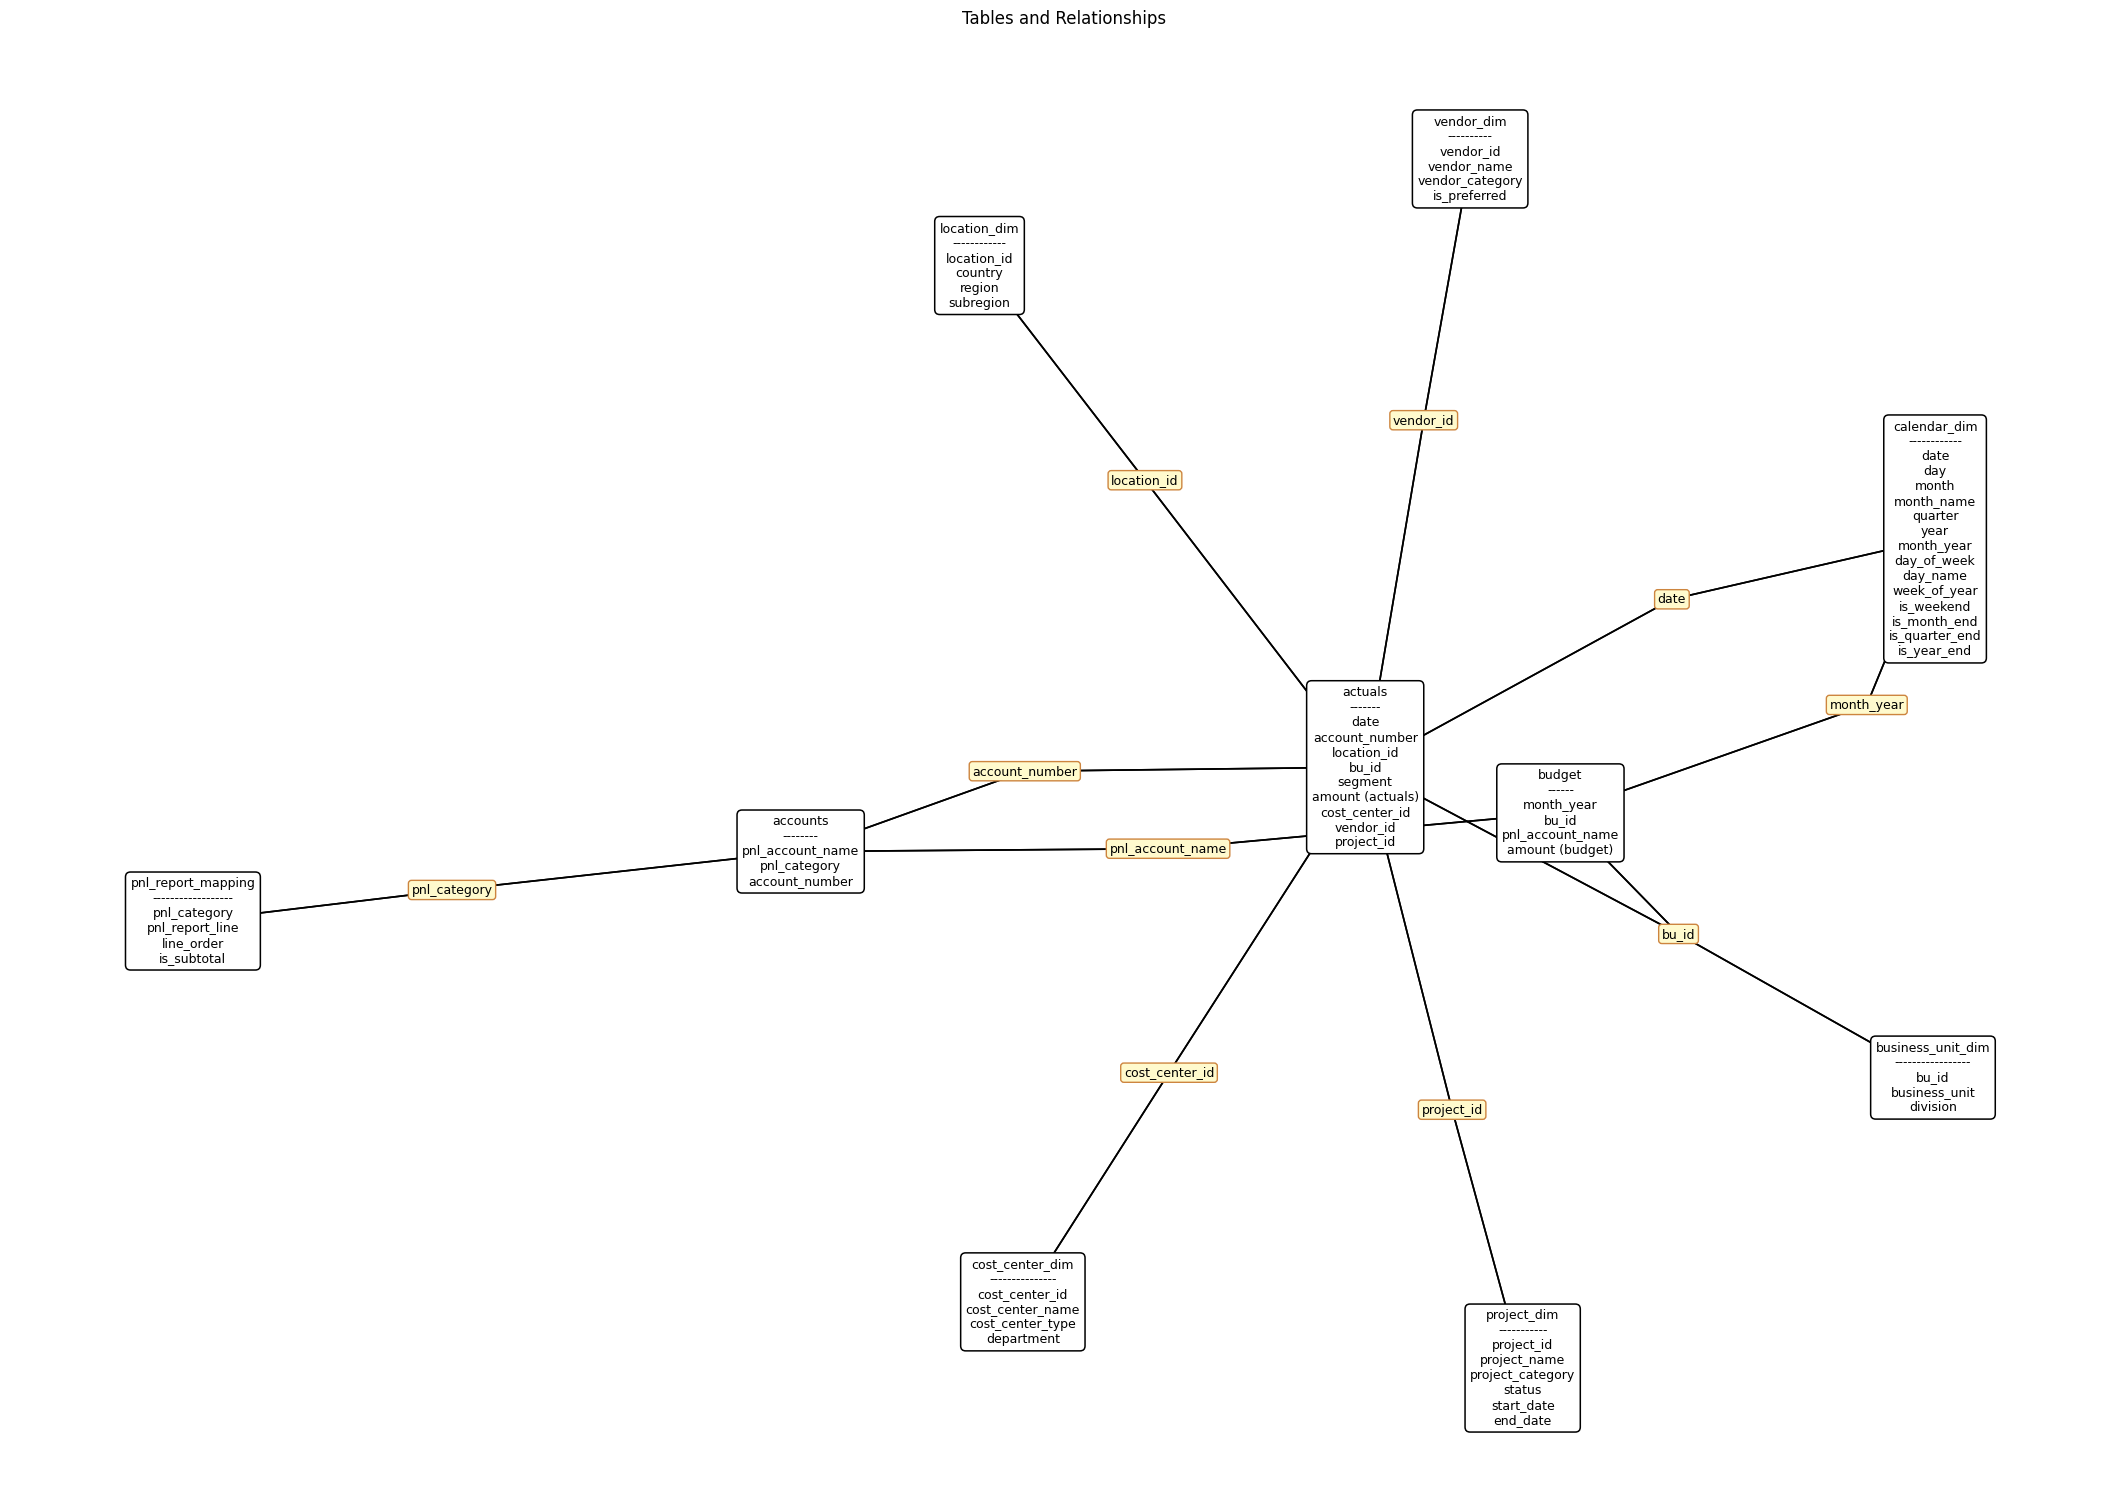

Cyclic relationships detected in the hypercube: calendar_dim -> budget -> accounts -> actuals
DataModel initialization failed: Cyclic relationships detected in the hypercube


Error creating Hypercube: Cyclic relationships detected in the hypercube


In [4]:
import copy
tables_working = copy.deepcopy(tables)
try:
    cube = Hypercube(tables_working, False)
except Exception as e:
    print("Error creating Hypercube:", e)

In [5]:
## We need to fix the circular references

actuals_prep = pd.merge(
    tables_working['actuals'][['date', 'account_number', 'bu_id']].drop_duplicates(),
    tables_working['calendar_dim'][['date', 'month_year']],
    on='date',
    how='left'
)

# Add pnl_account_name to actuals for linking with budget
actuals_dims = pd.merge(
    actuals_prep,
    tables_working['accounts'][['account_number', 'pnl_account_name']].drop_duplicates(),
    on='account_number',
    how='left'
).drop_duplicates()

# Step 2.2: Prepare budget dimension data
budget_dims = tables_working['budget'][['month_year', 'pnl_account_name', 'bu_id']].drop_duplicates()
# create a date as first date of the month for budget to connect to the calendar
budget_dims['date'] = budget_dims['month_year'].apply(lambda x: pd.to_datetime(x + '-01')).dt.date

#just in case...
actuals_dims['date'] = pd.to_datetime(actuals_dims['date']).dt.date
tables_working['calendar_dim']['date'] = pd.to_datetime(tables_working['calendar_dim']['date']).dt.date
# Step 2.3: Create the initial fact_link table with all distinct dimensions
# This creates one row for each unique combination of dimension values
fact_link_dims = pd.DataFrame()

# Add all distinct dimension values from actuals
fact_link_dims = pd.concat([
    fact_link_dims,
    actuals_dims
])

# Add all distinct dimension values from budget
fact_link_dims = pd.concat([
    fact_link_dims,
    budget_dims
])

# Remove duplicates to get unique combinations
fact_link_dims = fact_link_dims.drop_duplicates().reset_index(drop=True)

def create_composite_key(df, key_columns:list):
    column_name = ' | '.join(key_columns) + ' (key)'
    #I want to create a key by concatenating the values of the key columns
    df[column_name] = df[key_columns].astype(str).agg(' | '.join, axis=1)
    return df[column_name]


# Now create the keys with consistent data types
create_composite_key(fact_link_dims, ['date', 'account_number', 'bu_id'])

create_composite_key(fact_link_dims, ['month_year', 'pnl_account_name', 'bu_id'])

create_composite_key(tables_working['actuals'], ['date', 'account_number', 'bu_id'])

create_composite_key(tables_working['budget'], ['month_year', 'pnl_account_name', 'bu_id'])

fact_link_dims.drop(columns=['month_year'], inplace=True)
fact_link_dims

,date,account_number,bu_id,pnl_account_name,date | account_number | bu_id (key),month_year | pnl_account_name | bu_id (key)
0,2023-01-02,1101,7,Sales Returns,2023-01-02 | 1101 | 7,2023-01 | Sales Returns | 7
1,2023-01-02,1202,8,Net Revenue,2023-01-02 | 1202 | 8,2023-01 | Net Revenue | 8
2,2023-01-02,1203,1,Net Revenue,2023-01-02 | 1203 | 1,2023-01 | Net Revenue | 1
3,2023-01-02,2003,7,Direct Materials,2023-01-02 | 2003 | 7,2023-01 | Direct Materials | 7
4,2023-01-02,2103,4,Direct Labor,2023-01-02 | 2103 | 4,2023-01 | Direct Labor | 4
...,...,...,...,...,...,...
5329,2023-12-01,NaN,8,Rent,2023-12-01 | nan | 8,2023-12 | Rent | 8
5330,2023-12-01,NaN,8,Sales Commissions,2023-12-01 | nan | 8,2023-12 | Sales Commissions | 8
5331,2023-12-01,NaN,8,Sales Returns,2023-12-01 | nan | 8,2023-12 | Sales Returns | 8
5332,2023-12-01,NaN,8,Taxes,2023-12-01 | nan | 8,2023-12 | Taxes | 8


In [6]:
tables_working['actuals'].head()

,date,account_number,location_id,bu_id,segment,amount (actuals),cost_center_id,vendor_id,project_id,date | account_number | bu_id (key)
0,2023-01-02,1101,3,7,Government,-83.455964,11.0,NaN,NaN,2023-01-02 | 1101 | 7
1,2023-01-02,1202,2,8,Retail,1549.356443,NaN,NaN,NaN,2023-01-02 | 1202 | 8
2,2023-01-02,1203,5,1,Retail,1916.968972,NaN,NaN,NaN,2023-01-02 | 1203 | 1
3,2023-01-02,2003,11,7,Retail,-706.910525,12.0,12.0,NaN,2023-01-02 | 2003 | 7
4,2023-01-02,2103,7,4,Corporate,-767.484711,9.0,NaN,NaN,2023-01-02 | 2103 | 4


In [7]:
#remove columns from original actual and budget tables
tables_working['actuals'] = tables_working['actuals'].drop(columns=['date', 'account_number', 'bu_id'])
tables_working['budget'] = tables_working['budget'].drop(columns=['month_year', 'pnl_account_name', 'bu_id'])

In [8]:
tables_working['Link_Actuals_Budget'] = fact_link_dims

In [9]:
# store all tables into csv
if False:
    current_dir = Path.cwd()
    for table_name, df in tables_working.items():
        df.to_csv(current_dir / f"output/{table_name}.csv", index=False)


In [10]:
cube = Hypercube(tables_working,False)

In [ ]:
for ct, df in cube.composite_tables.items():
    print(f"Composite Table: {ct}")
    print('columns:', df.columns.tolist(),'\n')

In [11]:
# Now the original table will have the columns which are also keys renamed
cube.tables['Link_Actuals_Budget'].head(20)


,_index_Link_Actuals_Budget,_key__composite_key_account_number_pnl_account_name,_key_date | account_number | bu_id (key),_key_month_year | pnl_account_name | bu_id (key),_key_bu_id,_key_date
0,0,4,1,105,7,2
1,1,7,2,115,8,2
2,2,8,3,7,1,2
3,3,11,4,97,7,2
4,4,14,5,52,4,2
5,5,16,6,21,2,2
6,6,18,7,57,4,2
7,7,19,8,57,4,2
8,8,21,9,27,2,2
9,9,24,10,63,4,2


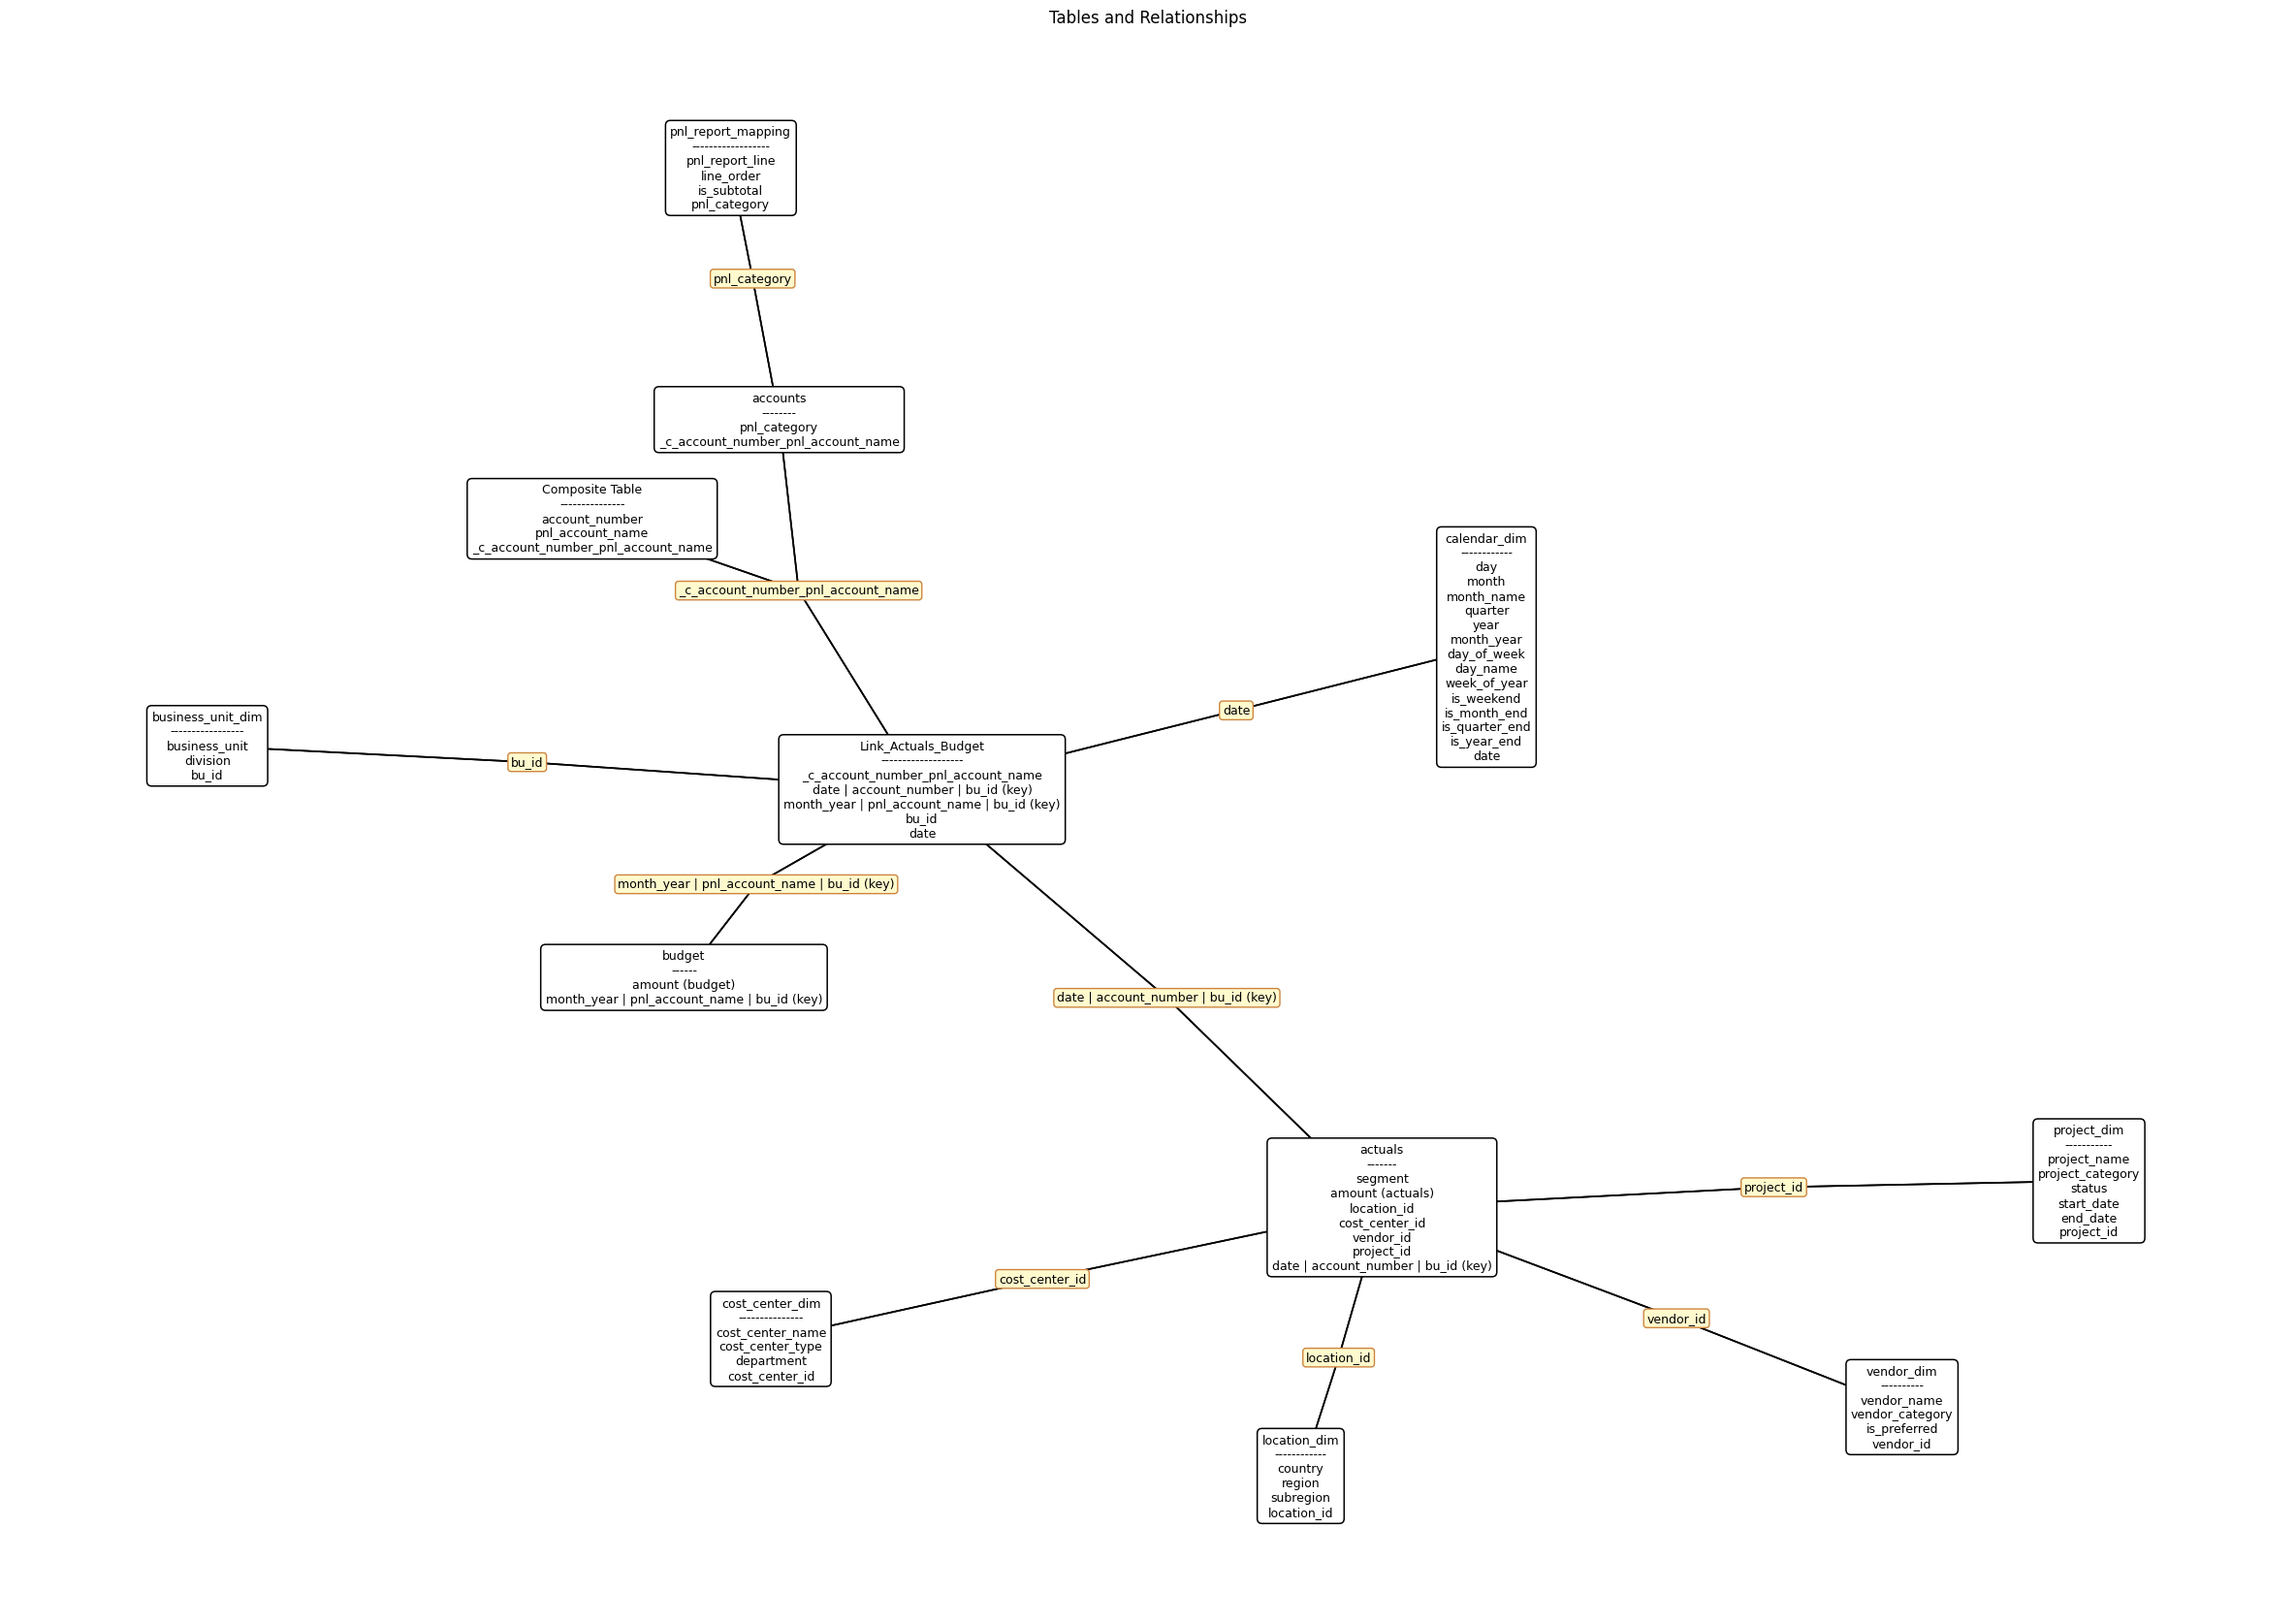

In [12]:
cube.visualize_graph(seed=21,full_column_names=False)

In [13]:
cube.define_metric(name='Amount Actual', expression='[amount (actuals)]', aggregation='sum')
cube.define_metric(name='Amount Budget', expression='[amount (budget)]', aggregation='sum')
cube.define_metric(name='_line_order_avg', expression='[line_order]', aggregation='mean')

cube.define_derived_metric(name='difference', expression='[Amount Actual] - [Amount Budget]')
cube.define_derived_metric(name='percentage_difference', expression='[difference] / [Amount Budget]')

#supporting metric
cube.define_query(name='PNL', metrics=['Amount Actual', 'Amount Budget'], derived_metrics = ['difference', 'percentage_difference'], dimensions=['pnl_report_line'], sort=[('_line_order_avg', 'asc')])
cube.query('PNL')

,pnl_report_line,Amount Actual,Amount Budget,difference,percentage_difference
9,Revenue,2.110612e+06,2.121609e+06,-10997.387312,-0.005184
0,Cost of Goods Sold,-2.686079e+05,-2.680919e+05,-515.938949,0.001924
5,Gross Margin,1.842004e+06,1.853517e+06,-11513.326261,-0.006212
8,Operating Expenses,-2.137758e+06,-2.119665e+06,-18093.023714,0.008536
3,EBITDA,-2.957542e+05,-2.661478e+05,-29606.349975,0.111240
1,Depreciation & Amortization,-1.760205e+04,-1.750848e+04,-93.575395,0.005345
2,EBIT,-3.133562e+05,-2.836563e+05,-29699.925370,0.104704
6,Interest,-8.874990e+04,-8.861017e+04,-139.724825,0.001577
4,EBT,-4.021061e+05,-3.722665e+05,-29839.650195,0.080157
10,Taxes,-8.874990e+04,-8.861017e+04,-139.724825,0.001577


In [14]:
#cube.dimensions(['line_order', 'pnl_report_line']).sort_values(by='line_order')
cube.define_query(name='test', dimensions=['line_order','pnl_report_line'], metrics=['_line_order_avg'])
cube.query('test')#.sort_values(by='_line_order_avg')

,line_order,pnl_report_line,_line_order_avg
0,10.0,Revenue,10.0
1,20.0,Cost of Goods Sold,20.0
2,30.0,Gross Margin,30.0
3,40.0,Operating Expenses,40.0
4,50.0,EBITDA,50.0
5,60.0,Depreciation & Amortization,60.0
6,70.0,EBIT,70.0
7,80.0,Interest,80.0
8,90.0,EBT,90.0
9,100.0,Taxes,100.0


In [15]:
cube.query(options={'metrics': ['Amount Actual']})

,Amount Actual
0,-402106.144924


In [16]:
import pickle

# I need to unregister all functions to be able to pickle
bkp_registered_functions = cube.registered_functions.keys()
print('registered functions:', bkp_registered_functions)
cube.registered_functions = {}

# I dont need the 'Default' context state either. I can init it later
#cube.context_states['Default'] = None

# Save your cube object
with open(current_dir / "cube_pnl.pkl", 'wb') as f:
    pickle.dump(cube, f)

print(f"cube saved without registered functions. Remember to register them back. Functions: {bkp_registered_functions}")

#register functions back. __builtins__ will be automatically added
import numpy as np
cube.registered_functions = {
        'pd': pd,
        'np': np
    }

registered functions: dict_keys(['pd', 'np', '__builtins__'])
cube saved without registered functions. Remember to register them back. Functions: dict_keys(['pd', 'np', '__builtins__'])


In [17]:
# Default plot configuration
cube.define_plot(
    query_name='PNL',
    plot_name='Default2',
    plot_type='bar',
    dimensions=['pnl_report_line'],
    metrics=['Amount Actual'],
    #orientation='horizontal',
    title='Actual by P&L Report Line',
    sort_values=True,
    sort_ascending=False
)

# Comparison plot configuration
cube.define_plot(
    query_name='PNL',
    plot_name='comparison',
    plot_type='bar',
    dimensions=['pnl_report_line'],
    metrics=['Amount Budget'],
    title='P&L Budget Amount',
    orientation='horizontal',
    sort_values=True,
    sort_ascending=False,
    set_as_default=False  # Don't make this the default
)

# Variance plot configuration
cube.define_plot(
    query_name='PNL',
    plot_name='variance',
    plot_type='bar',
    dimensions=['pnl_report_line'],
    metrics=['difference'],
    title='P&L Variance',
    orientation='horizontal',
    sort_values=True,
    sort_ascending=False,
    set_as_default=False
)

# List available plot configurations
print("Available plot configurations for PNL query:", cube.list_plots('PNL'))
#print("Default plot:", cube.default_plots.get('PNL'))

Available plot configurations for PNL query: ['Default2', 'comparison', 'variance']


In [18]:
# Need to set context state after loading the cube or unpickling it
# This ensures the cube has a valid state for querying
cube.set_context_state('Default')

# Use it with default plot configuration
#fig = cube.plot('PNL', show = True)

if False:
    # Use a different plot configuration
    cube.plot('PNL', plot_name='variance')

    # Try with customized configuration
    cube.plot(
        'PNL',
        metrics=['percentage_difference'],  # Change metric
        title='Percentage Difference',      # Custom title
        sort_values=True                    # Sort by values
    )



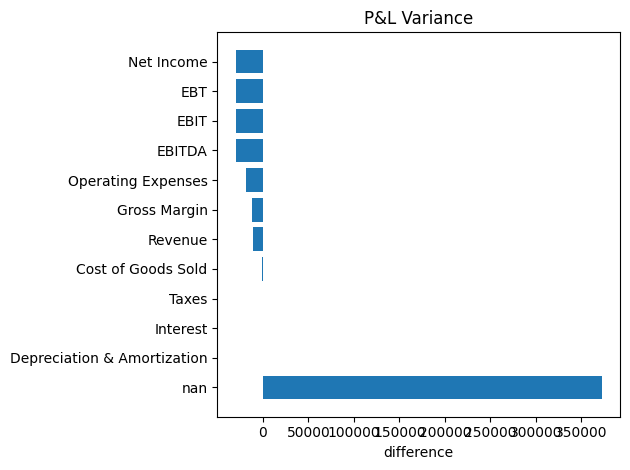

In [19]:
cube.plot('PNL',plot_type='bar',plot_name='variance')

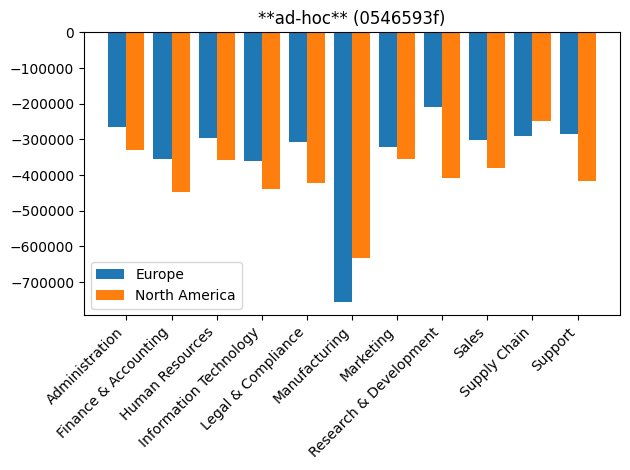

In [20]:
cube.plot(query_options={'dimensions': ['department','region'], 'metrics': ['Amount Budget']})


In [21]:
cube.relationship_matrix()

,account_number,pnl_account_name,vendor_id,pnl_category,cost_center_id,month_year | pnl_account_name | bu_id (key),date,date | account_number | bu_id (key),project_id,bu_id,location_id
0,NaN,Direct Labor,NaN,NaN,NaN,2023-01 | Direct Labor | 1,2023-01-01,2023-01-01 | nan | 1,NaN,1.0,NaN
1,NaN,Direct Materials,NaN,NaN,NaN,2023-01 | Direct Materials | 1,2023-01-01,2023-01-01 | nan | 1,NaN,1.0,NaN
2,NaN,Gross Revenue,NaN,NaN,NaN,2023-01 | Gross Revenue | 1,2023-01-01,2023-01-01 | nan | 1,NaN,1.0,NaN
3,NaN,Interest,NaN,NaN,NaN,2023-01 | Interest | 1,2023-01-01,2023-01-01 | nan | 1,NaN,1.0,NaN
4,NaN,Manufacturing Overhead,NaN,NaN,NaN,2023-01 | Manufacturing Overhead | 1,2023-01-01,2023-01-01 | nan | 1,NaN,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
5406,2104,Direct Labor,NaN,COGS,11.0,2023-12 | Direct Labor | 8,2023-12-29,2023-12-29 | 2104 | 8,NaN,8.0,11.0
5407,3201,Sales Commissions,NaN,Operating Expenses,7.0,2023-12 | Sales Commissions | 8,2023-12-29,2023-12-29 | 3201 | 8,NaN,8.0,12.0
5408,1101,Sales Returns,NaN,Revenue,2.0,2023-12 | Sales Returns | 8,2023-12-29,2023-12-29 | 1101 | 8,NaN,8.0,1.0
5409,NaN,NaN,NaN,NaN,NaN,NaN,2023-12-30,NaN,NaN,NaN,NaN
